# Robo2VLM-1 Dataset Categorization using LLM Judge on Colab GPU

This notebook categorizes questions from the Robo2VLM-1 dataset into spatial reasoning, affordance understanding, or neither using a small open-sourced LLM (Phi-2) as a judge.

In [1]:
# Enable GPU in Google Colab
# Make sure to select GPU runtime in Colab: Runtime > Change runtime type > Hardware accelerator > GPU

import torch
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected. Please enable GPU runtime.")

GPU available: True
GPU name: Tesla T4


In [2]:
# Install Required Libraries
!pip install datasets transformers torch accelerate

In [3]:
# Optional: Login to Hugging Face (if needed for large downloads or private models)
# Uncomment and run if you encounter authentication issues
from huggingface_hub import login
login()  # This will prompt for your HF token

In [4]:
# Load the Small Open-Sourced LLM Model
from transformers import AutoTokenizer, AutoModelForCausalLM, PhiConfig

model_name = "microsoft/phi-2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

config = PhiConfig.from_pretrained(model_name)
config.pad_token_id = tokenizer.pad_token_id

model = AutoModelForCausalLM.from_pretrained(model_name, config=config, torch_dtype=torch.float16, device_map="auto")

print("Model loaded on device:", model.device)

config.json:   0%|          | 0.00/735 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model loaded on device: cuda:0


In [5]:
# Prepare Input Data for Categorization
from datasets import load_dataset, Features, Value, Image

# Specify features to avoid decoding image
features = Features({
    'id': Value('string'),
    'question': Value('string'),
    'choices': Value('string'),
    'correct_answer': Value('int64'),
    'image': Image(decode=False),
})

split = 'test'
dataset = load_dataset("keplerccc/Robo2VLM-1", streaming=True, features=features, split=split)
# Note: When split is specified, dataset is the IterableDataset for that split directly

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/262 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/262 [00:00<?, ?it/s]

In [6]:
# Run Categorization Inference on GPU
import json

def classify_question(question, tokenizer, model):
    prompt = """You are an AI judge tasked with categorizing questions from a robotics VQA dataset into one of three categories: 'spatial', 'affordance', or 'neither'.

Definitions:
- Spatial reasoning: Questions that involve understanding relative positions, directions, distances, orientations, alignments, or geometric relationships between objects, the robot, or the environment. Examples: "What's the relative direction between object X and the gripper?", "How far is the object from the robot?", "Is the object to the left of the gripper?"

- Affordance understanding: Questions that involve understanding what actions or manipulations are possible with objects, such as reachability, graspability, movability, or interaction capabilities. Examples: "Is object X reachable?", "Can the robot grasp this object?", "Is this object movable?"

- Neither: Questions that do not fit into spatial reasoning or affordance understanding, such as general object recognition, counting, or other unrelated topics.

Classify the following question into exactly one category: spatial, affordance, or neither. Respond with only the category name.

Question: {question}

Category:"""
    prompt = prompt.format(question=question)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=20, do_sample=False, temperature=0.0)
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    # Extract the category after "Category:"
    answer_part = response.split("Category:")[-1].strip().lower()
    if 'spatial' in answer_part:
        return 'spatial'
    elif 'affordance' in answer_part:
        return 'affordance'
    else:
        return 'neither'

spatial_indices = []
affordance_indices = []
i = 0
for sample in dataset:  # dataset is already the specified split
    question = sample['question']
    category = classify_question(question, tokenizer, model)
    if category == 'spatial':
        spatial_indices.append(i)
    elif category == 'affordance':
        affordance_indices.append(i)
    i += 1
    if i % 100 == 0:
        print(f"Processed {i} samples")
    if i >= 1000:  # For testing, limit to 1000; remove for full run
        break

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Se

Processed 100 samples


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end gene

Processed 200 samples


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end gene

...

Processed 800 samples


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end gene

Processed 900 samples


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end gene

Processed 1000 samples


In [7]:
# Process and Display Categorization Results
# Save indices
with open(f'{split}_spatial_indices.json', 'w') as f:
    json.dump(spatial_indices, f)
with open(f'{split}_affordance_indices.json', 'w') as f:
    json.dump(affordance_indices, f)

print(f"Finished: spatial {len(spatial_indices)}, affordance {len(affordance_indices)}")

# Display sample results
print("Sample spatial indices:", spatial_indices[:10])
print("Sample affordance indices:", affordance_indices[:10])

Finished: spatial 187, affordance 801
Sample spatial indices: [52, 78, 82, 83, 188, 203, 241, 244, 249, 253]
Sample affordance indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


ID: fractal20220817_data_place_blue_plastic_bottle_into_middle_drawer_3973_q43
Question: Is there any obstacle blocking the robot from reaching bottle?
Choices: ['No', 'Cannot be determined', 'Partially reachable', 'Yes']
Correct Answer: 0


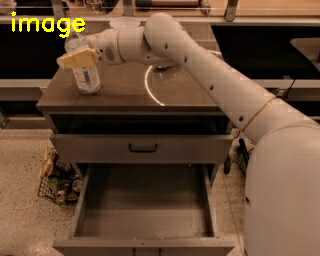

In [11]:
import io
from PIL import Image
from IPython.display import display

sample = next(iter(dataset))

print(f"ID: {sample['id']}")
print(f"Question: {sample['question']}")
print(f"Choices: {sample['choices']}")
print(f"Correct Answer: {sample['correct_answer']}")

# Decode the image bytes and display
img_bytes = sample['image']['bytes']
img = Image.open(io.BytesIO(img_bytes))
display(img)

Index: 127
ID: stanford_kuka_multimodal_dataset_converted_externally_to_rlds_insert_the_peg_into_the_hole_141_q27
Question: Is the robot's grasp of the peg stable?
Choices: ['Partially stable', 'No', 'Yes', 'Cannot be determined']


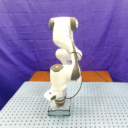

In [17]:
import itertools

def display_sample_at_index(dataset, target_index):
    # Use islice to skip to the target index without loading everything into memory
    sample = next(itertools.islice(dataset, target_index, None))

    print(f"Index: {target_index}")
    print(f"ID: {sample['id']}")
    print(f"Question: {sample['question']}")
    print(f"Choices: {sample['choices']}")

    img_bytes = sample['image']['bytes']
    img = Image.open(io.BytesIO(img_bytes))
    display(img)

# Example: Display the first 'spatial' reasoning sample found (index 52)
target = 127
display_sample_at_index(dataset, target)